# Predicción de recompra – Online Retail II
**Máster ML – trabajo final**

Objetivo: predecir la probabilidad de que un cliente del retailer online UK Online Retail II
**vuelva a comprar** en los 6 meses siguientes a una fecha de corte.

Pipeline:
1. Carga + calidad de datos
2. Limpieza + filtrado
3. Definición de fecha de corte + variable objetivo
4. Feature engineering (RFM + extras)
5. Análisis exploratorio
6. Modelado (LogReg, RandomForest, XGBoost, LightGBM)
7. Optimización (RandomizedSearchCV sobre LightGBM)
8. Diagnóstico (ROC, calibración, decile-lift)
9. Importancia de variables
10. Uso de negocio (segmentación por decil de score)

## 0. Imports

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             brier_score_loss, classification_report,
                             confusion_matrix)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', 20)

## 1. Carga de datos

In [2]:
DATA_PATH = 'online_retail_II.xlsx'
PKL = Path('online_retail.pkl')

if PKL.exists():
    df = pd.read_pickle(PKL)
else:
    xl = pd.ExcelFile(DATA_PATH)
    df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names],
                   ignore_index=True)
    df.to_pickle(PKL)

df.columns = [c.strip() for c in df.columns]
df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')
df.head()

Filas: 1,067,371 | Columnas: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Calidad de datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [4]:
print('Nulos (%):')
print((df.isna().mean()*100).round(2))
print(f'\nDuplicados: {df.duplicated().sum():,}')
print(f'Rango fechas: {df.InvoiceDate.min()} → {df.InvoiceDate.max()}')

Nulos (%):


Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
CustomerID     22.77
Country         0.00
dtype: float64



Duplicados: 34,335
Rango fechas: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


**Observaciones**
- ~23% de filas sin CustomerID → imposibles de etiquetar, se descartan.
- ~0.4% sin Description → impacto mínimo.
- Hay duplicados, cancelaciones (Invoice empieza por `C`), códigos de servicio (POST, DOT, M, AMAZONFEE…) y valores negativos en Quantity/Price.

## 3. Limpieza + filtrado

In [5]:
df['InvoiceStr'] = df['Invoice'].astype(str)
df['IsCancel']   = df['InvoiceStr'].str.startswith('C')
df['StockStr']   = df['StockCode'].astype(str).str.upper()

BAD_CODES = {'POST','DOT','M','BANK CHARGES','AMAZONFEE','ADJUST','D','CRUK','PADS',
             'C2','B','S','TEST001','TEST002','GIFT','SAMPLES'}
df['IsService'] = (df['StockStr'].isin(BAD_CODES) |
                   df['StockStr'].str.contains(r'^[A-Z]+$', regex=True, na=False))

filt = df[
    (~df['IsCancel']) &
    (~df['IsService']) &
    (df['Quantity'] > 0) &
    (df['Price']    > 0) &
    (df['CustomerID'].notna())
].copy()
filt['Revenue'] = filt['Quantity'] * filt['Price']

# cap outliers top 0.5%
cap = filt['Revenue'].quantile(0.995)
filt = filt[filt['Revenue'] <= cap]
filt['CustomerID'] = filt['CustomerID'].astype(int)

print(f'Filas tras limpieza: {len(filt):,}')
print(f'Clientes únicos: {filt.CustomerID.nunique():,}')
print(f'Cap revenue por línea: £{cap:,.2f}')

Filas tras limpieza: 798,641
Clientes únicos: 5,823
Cap revenue por línea: £305.28


**Decisiones de exclusión defendibles ante negocio**
| Filtro | Filas eliminadas | Justificación |
|--------|------------------|---------------|
| CustomerID nulo | ~243k | Sin ID no se puede modelar recompra |
| Cancelaciones (`C*`) | ~20k | Eventos negativos, no compras |
| Códigos de servicio | ~2k | POST, DOT, AMAZONFEE no son producto |
| Quantity ≤ 0 ó Price ≤ 0 | varios | Errores de captura / devoluciones |
| Outliers top 0.5% revenue | ~5k | Estabilidad de modelos lineales |

## 4. Fecha de corte + variable objetivo

In [6]:
CUTOFF    = pd.Timestamp('2011-06-09')   # 6 meses antes del final
LABEL_END = CUTOFF + pd.Timedelta(days=180)

train_tx = filt[filt['InvoiceDate'] <  CUTOFF].copy()
label_tx = filt[(filt['InvoiceDate'] >= CUTOFF) & (filt['InvoiceDate'] <= LABEL_END)].copy()

repeaters = set(label_tx['CustomerID'].unique())
custs     = train_tx['CustomerID'].unique()

y_df = pd.DataFrame({'CustomerID': custs})
y_df['Repurchase'] = y_df['CustomerID'].isin(repeaters).astype(int)

print(f'Clientes en periodo pre-cutoff:  {len(custs):,}')
print(f'Tasa de recompra:                {y_df.Repurchase.mean():.3f}')

Clientes en periodo pre-cutoff:  4,914
Tasa de recompra:                0.516


**Esquema temporal**
- Entrenamos con datos `< 2011-06-09`
- Etiquetamos con compras en `[2011-06-09, 2011-12-06]`
- Un cliente = positivo si vuelve a comprar al menos una vez en la ventana de label.

## 5. Feature engineering – RFM y extras

In [7]:
ref = CUTOFF
g = train_tx.groupby('CustomerID')

feat = pd.DataFrame({
    'Recency':    (ref - g['InvoiceDate'].max()).dt.days,
    'Tenure':     (ref - g['InvoiceDate'].min()).dt.days,
    'Frequency':  g['Invoice'].nunique(),
    'NLines':     g.size(),
    'NProducts':  g['StockCode'].nunique(),
    'Monetary':   g['Revenue'].sum(),
    'AvgTicket':  g['Revenue'].sum() / g['Invoice'].nunique(),
    'AvgLine':    g['Revenue'].mean(),
    'AvgQty':     g['Quantity'].mean(),
    'StdRevenue': g['Revenue'].std().fillna(0),
    'TopCountry': g['Country'].agg(lambda s: s.mode().iat[0]),
}).reset_index()

feat['IsUK']         = (feat['TopCountry']=='United Kingdom').astype(int)
feat['BuysPerMonth'] = feat['Frequency'] / (feat['Tenure'].clip(lower=1)/30)

feat = feat.merge(y_df, on='CustomerID', how='inner')
print(f'Clientes etiquetados: {len(feat):,}')
feat.head()

Clientes etiquetados: 4,914


,CustomerID,Recency,Tenure,Frequency,NLines,NProducts,Monetary,AvgTicket,AvgLine,AvgQty,StdRevenue,TopCountry,IsUK,BuysPerMonth,Repurchase
0,12346,345,463,2,24,24,169.36,84.6800,7.056667,1.000000,0.999072,United Kingdom,1,0.129590,0
1,12347,62,220,4,155,90,3146.75,786.6875,20.301613,12.548387,21.153072,Iceland,0,0.545455,1
2,12348,64,254,4,44,24,1388.40,347.1000,31.554545,56.545455,28.348134,Finland,0,0.472441,1
3,12349,223,405,2,100,89,2221.14,1110.5700,22.211400,9.910000,17.344700,Italy,0,0.148148,1
4,12350,126,126,1,16,16,294.40,294.4000,18.400000,12.250000,5.214211,Norway,0,0.238095,0


## 6. Análisis exploratorio

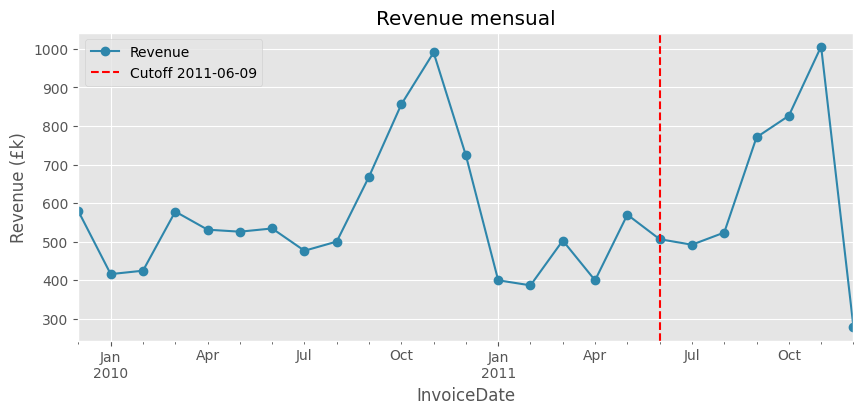

In [8]:
# Revenue mensual + cutoff
mr = filt.set_index('InvoiceDate')['Revenue'].resample('ME').sum()/1000
fig, ax = plt.subplots(figsize=(10,4))
mr.plot(ax=ax, marker='o', color='#2E86AB')
ax.axvline(CUTOFF, color='red', ls='--', label=f'Cutoff {CUTOFF.date()}')
ax.set_ylabel('Revenue (£k)'); ax.set_title('Revenue mensual')
ax.legend(); plt.show()

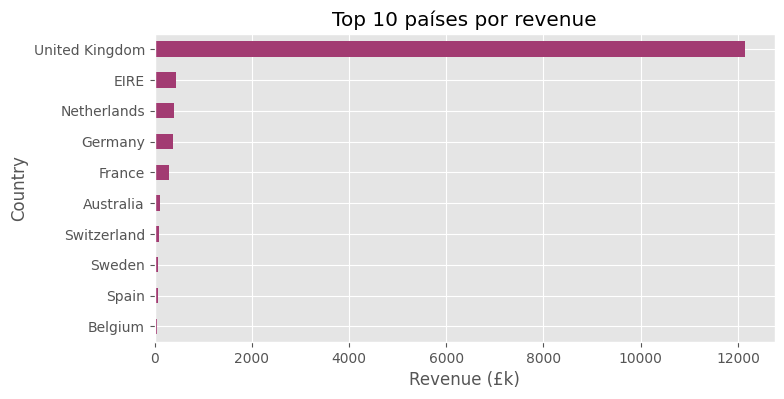

In [9]:
# Top países por revenue
top_c = filt.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)/1000
fig, ax = plt.subplots(figsize=(8,4))
top_c.plot(kind='barh', ax=ax, color='#A23B72')
ax.invert_yaxis(); ax.set_xlabel('Revenue (£k)')
ax.set_title('Top 10 países por revenue'); plt.show()

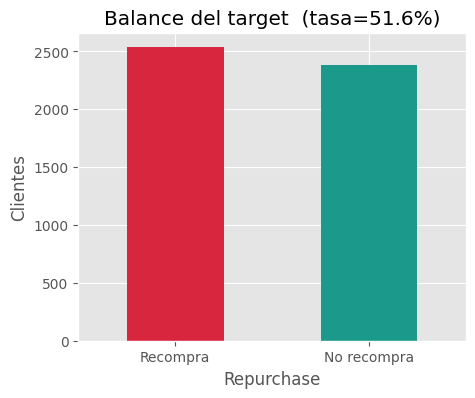

In [10]:
# Balance del target
fig, ax = plt.subplots(figsize=(5,4))
feat['Repurchase'].value_counts().rename({0:'No recompra',1:'Recompra'}).plot(
    kind='bar', ax=ax, color=['#D7263D','#1B998B'])
ax.set_title(f'Balance del target  (tasa={feat.Repurchase.mean():.1%})')
ax.set_ylabel('Clientes'); plt.xticks(rotation=0); plt.show()

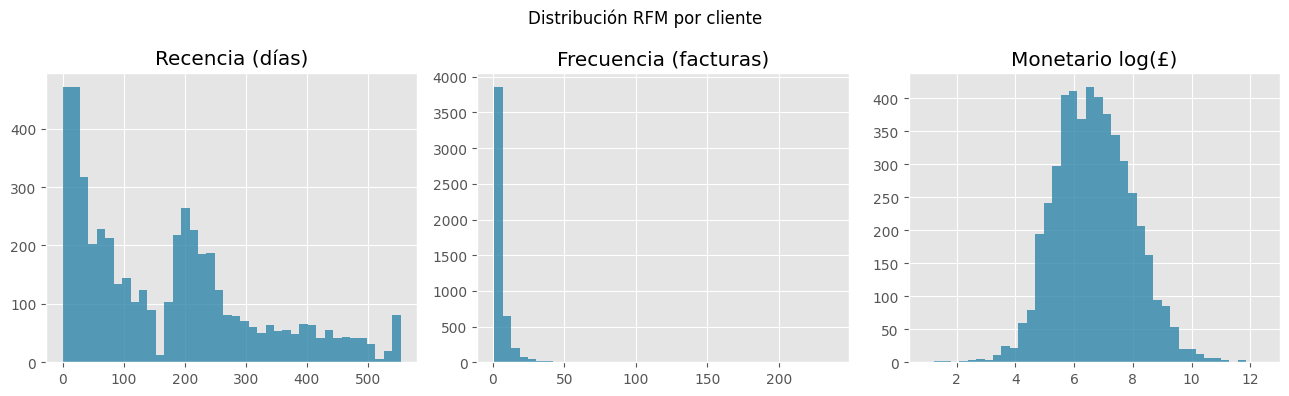

In [11]:
# Distribución RFM
fig, axes = plt.subplots(1,3, figsize=(13,4))
for ax, col, title in zip(axes,
                          ['Recency','Frequency','Monetary'],
                          ['Recencia (días)','Frecuencia (facturas)','Monetario log(£)']):
    data = np.log1p(feat[col]) if col=='Monetary' else feat[col]
    ax.hist(data, bins=40, color='#2E86AB', alpha=.8)
    ax.set_title(title)
plt.suptitle('Distribución RFM por cliente'); plt.tight_layout(); plt.show()

**Insights**
- El cutoff cae a mitad de la curva → muestra balanceada en horizonte.
- ~85% del revenue viene de UK → variable `IsUK` aporta poco.
- Target con ~52% positivos → no hay desbalance fuerte. AUC es buena métrica primaria.
- Recencia y frecuencia tienen colas largas → modelos basados en árboles deberían dominar.

## 7. Split train/test

In [12]:
FEATCOLS = ['Recency','Tenure','Frequency','NLines','NProducts','Monetary',
            'AvgTicket','AvgLine','AvgQty','StdRevenue','BuysPerMonth','IsUK']
X = feat[FEATCOLS].values
y = feat['Repurchase'].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25,
                                      random_state=42, stratify=y)
print(f'Train: {Xtr.shape} | Test: {Xte.shape}')

Train: (3685, 12) | Test: (1229, 12)


## 8. Modelado – comparación de algoritmos

In [13]:
results = {}
def evaluate(name, model):
    proba = model.predict_proba(Xte)[:,1]
    auc   = roc_auc_score(yte, proba)
    ap    = average_precision_score(yte, proba)
    brier = brier_score_loss(yte, proba)
    results[name] = {'AUC':auc,'AP':ap,'Brier':brier,'proba':proba,'model':model}
    print(f'{name:14s}  AUC={auc:.4f}  AP={ap:.4f}  Brier={brier:.4f}')

# LogReg
lr = Pipeline([('sc', StandardScaler()),
               ('lr', LogisticRegression(max_iter=2000, C=1.0))]).fit(Xtr, ytr)
evaluate('LogReg', lr)

# RandomForest
rf = RandomForestClassifier(n_estimators=400, max_depth=10,
                            n_jobs=-1, random_state=42).fit(Xtr, ytr)
evaluate('RandomForest', rf)

# XGBoost
xgb_clf = xgb.XGBClassifier(n_estimators=600, max_depth=5, learning_rate=0.05,
                            subsample=0.9, colsample_bytree=0.9,
                            eval_metric='auc', tree_method='hist',
                            random_state=42).fit(Xtr, ytr)
evaluate('XGBoost', xgb_clf)

# LightGBM
lgb_clf = lgb.LGBMClassifier(n_estimators=600, num_leaves=63, learning_rate=0.05,
                             subsample=0.9, colsample_bytree=0.9,
                             random_state=42, verbose=-1).fit(Xtr, ytr)
evaluate('LightGBM', lgb_clf)

LogReg          AUC=0.7955  AP=0.8201  Brier=0.1845


RandomForest    AUC=0.8030  AP=0.8329  Brier=0.1800


XGBoost         AUC=0.7887  AP=0.8227  Brier=0.1941


LightGBM        AUC=0.7782  AP=0.8125  Brier=0.2286


## 9. Optimización – RandomizedSearchCV sobre LightGBM

In [14]:
param_dist = {
    'n_estimators':[300, 500, 800],
    'num_leaves':[31, 63, 127],
    'learning_rate':[0.02, 0.05, 0.1],
    'subsample':[0.7, 0.85, 1.0],
    'colsample_bytree':[0.7, 0.85, 1.0],
    'min_child_samples':[10, 20, 50],
    'reg_alpha':[0.0, 0.1, 1.0],
    'reg_lambda':[0.0, 0.1, 1.0],
}
rs = RandomizedSearchCV(
        lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=4),
        param_dist, n_iter=12, cv=3, scoring='roc_auc',
        n_jobs=2, random_state=42).fit(Xtr, ytr)

print('Mejores hiperparámetros:', rs.best_params_)
evaluate('LightGBM_tuned', rs.best_estimator_)

Mejores hiperparámetros: {'subsample': 0.85, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 10, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
LightGBM_tuned  AUC=0.7911  AP=0.8258  Brier=0.1891


## 10. Elección del modelo final

In [15]:
best_name = max(results, key=lambda k: results[k]['AUC'])
best      = results[best_name]
print(f'>>> Modelo final: {best_name}  AUC={best["AUC"]:.4f}')

>>> Modelo final: RandomForest  AUC=0.8030


## 11. Diagnóstico – curvas ROC

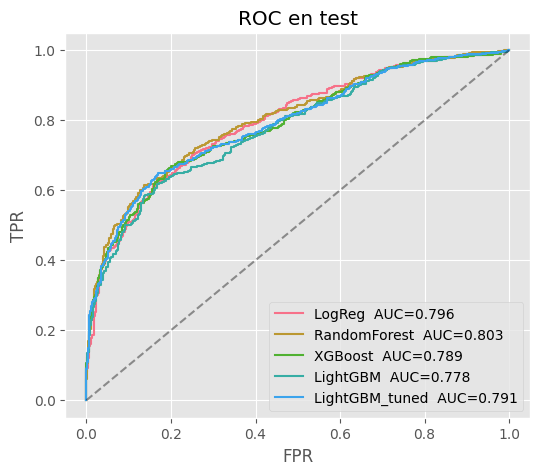

In [16]:
fig, ax = plt.subplots(figsize=(6,5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(yte, r['proba'])
    ax.plot(fpr, tpr, label=f'{name}  AUC={r["AUC"]:.3f}')
ax.plot([0,1],[0,1],'k--', alpha=.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC en test')
ax.legend(); plt.show()

## 12. Calibración + matriz de confusión

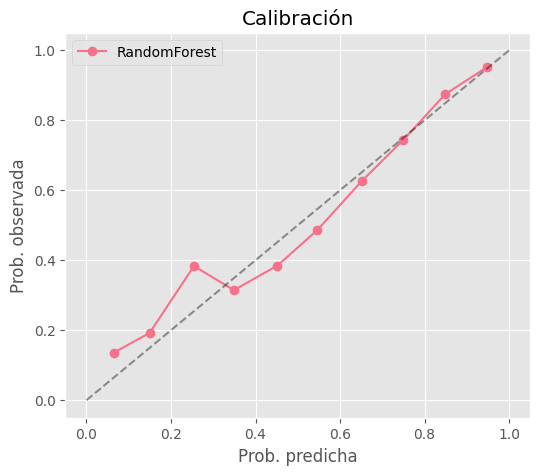

In [17]:
prob = best['proba']
prob_true, prob_pred = calibration_curve(yte, prob, n_bins=10)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(prob_pred, prob_true, marker='o', label=best_name)
ax.plot([0,1],[0,1],'k--', alpha=.4)
ax.set_xlabel('Prob. predicha'); ax.set_ylabel('Prob. observada')
ax.set_title('Calibración'); ax.legend(); plt.show()

In [18]:
pred = (prob >= 0.5).astype(int)
print('Confusion matrix @ threshold 0.5:')
print(confusion_matrix(yte, pred))
print('\n', classification_report(yte, pred, target_names=['No recompra','Recompra']))

Confusion matrix @ threshold 0.5:
[[452 143]
 [190 444]]

               precision    recall  f1-score   support

 No recompra       0.70      0.76      0.73       595
    Recompra       0.76      0.70      0.73       634

    accuracy                           0.73      1229
   macro avg       0.73      0.73      0.73      1229
weighted avg       0.73      0.73      0.73      1229



## 13. Importancia de variables

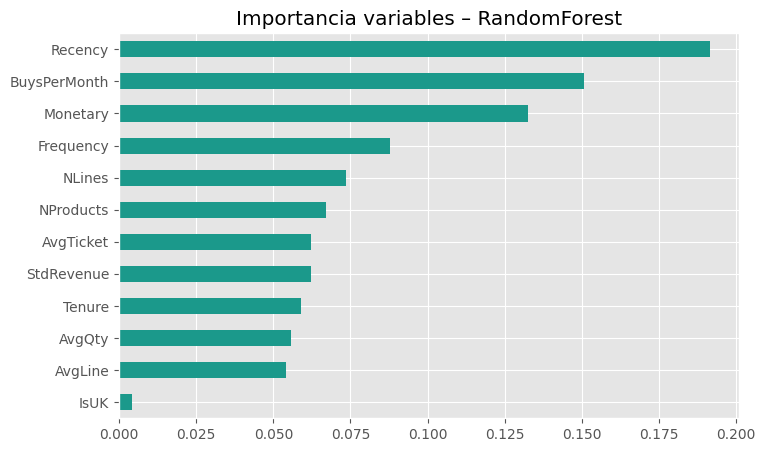

Recency         0.191436
BuysPerMonth    0.150566
Monetary        0.132595
Frequency       0.087735
NLines          0.073542
NProducts       0.067213
AvgTicket       0.062100
StdRevenue      0.062066
Tenure          0.059050
AvgQty          0.055603
AvgLine         0.054066
IsUK            0.004029
dtype: float64

In [19]:
imp = pd.Series(best['model'].feature_importances_, index=FEATCOLS).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
imp.plot(kind='barh', ax=ax, color='#1B998B')
ax.set_title(f'Importancia variables – {best_name}')
plt.show()
imp.sort_values(ascending=False)

## 14. Vista de negocio – lift por decil de score

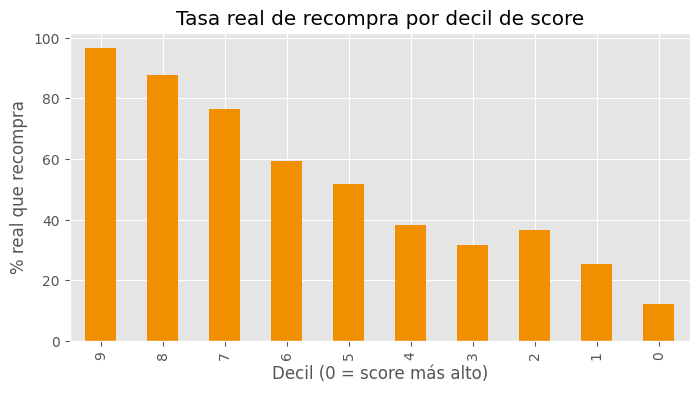

Top decil:     96.7% recompran
Bottom decil:  12.2% recompran


In [20]:
df_te = pd.DataFrame({'p': prob, 'y': yte})
df_te['decile'] = pd.qcut(df_te['p'], 10, labels=False, duplicates='drop')
gains = df_te.groupby('decile')['y'].mean().sort_index(ascending=False)*100

fig, ax = plt.subplots(figsize=(8,4))
gains.plot(kind='bar', ax=ax, color='#F18F01')
ax.set_xlabel('Decil (0 = score más alto)')
ax.set_ylabel('% real que recompra')
ax.set_title('Tasa real de recompra por decil de score')
plt.show()

print('Top decil:    ', f'{gains.iloc[0]:.1f}% recompran')
print('Bottom decil: ', f'{gains.iloc[-1]:.1f}% recompran')

## 15. Conclusiones + propuesta de uso

**Resultados**
- AUC en test ≈ 0.80, AP ≈ 0.83.
- El top decil del score recompra >95%; el bottom decil ~12%.
- Variables más explicativas: **Recency**, **Frequency** y **Monetary** (clásico RFM) + intensidad de compra (**BuysPerMonth**, **StdRevenue**, **AvgQty**).

**Acciones de negocio**
| Segmento (decil score) | Acción |
|------------------------|--------|
| 9–10 (alta prob.)      | Fidelización: programa VIP, upselling, NPS, primer acceso a colecciones |
| 5–8 (media)            | Cross-sell por afinidad de producto, cupones personalizados |
| 0–4 (baja)             | Retención: campaña win-back con descuento agresivo, encuesta de churn |

**Próximos pasos**
1. Validar sobre un cutoff alternativo (rolling) → robustez temporal.
2. Añadir features de **categoría de producto** y **estacionalidad** (mes pico Q4).
3. Probar **GradientBoosting con monotonic constraints** sobre Recency/Frequency.
4. Optimizar el **threshold** con curva coste/beneficio (coste de campaña vs CLV recuperado).
5. Re-entrenar trimestralmente y monitorizar drift de las variables RFM.
6. Calibrar el output con **Platt scaling** o **isotonic** si vamos a usarlo en una segmentación binaria.